In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

import dask.dataframe as dd
from sklearn.model_selection import RandomizedSearchCV


In [4]:
df = pd.read_csv('AIML Dataset.csv')

In [5]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736848 entries, 0 to 736847
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            736848 non-null  int64  
 1   type            736848 non-null  object 
 2   amount          736848 non-null  float64
 3   nameOrig        736847 non-null  object 
 4   oldbalanceOrg   736847 non-null  float64
 5   newbalanceOrig  736847 non-null  float64
 6   nameDest        736847 non-null  object 
 7   oldbalanceDest  736847 non-null  float64
 8   newbalanceDest  736847 non-null  float64
 9   isFraud         736847 non-null  float64
 10  isFlaggedFraud  736847 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 61.8+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,736848.000000,7.368480e+05,7.368470e+05,7.368470e+05,7.368470e+05,7.368470e+05,736847.000000,736847.0
mean,19.302760,1.638421e+05,8.753709e+05,8.956310e+05,9.811505e+05,1.137452e+06,0.000584,0.0
std,9.246904,2.696256e+05,2.938818e+06,2.975823e+06,2.317074e+06,2.459709e+06,0.024150,0.0
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,13.000000,1.295395e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,17.000000,7.874358e+04,1.665300e+04,0.000000e+00,1.209578e+05,2.185865e+05,0.000000,0.0
75%,22.000000,2.193005e+05,1.496120e+05,1.902127e+05,9.075471e+05,1.178238e+06,0.000000,0.0
max,38.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.148270e+07,4.148270e+07,1.000000,0.0


In [ ]:
df['isFraud'].value_counts()

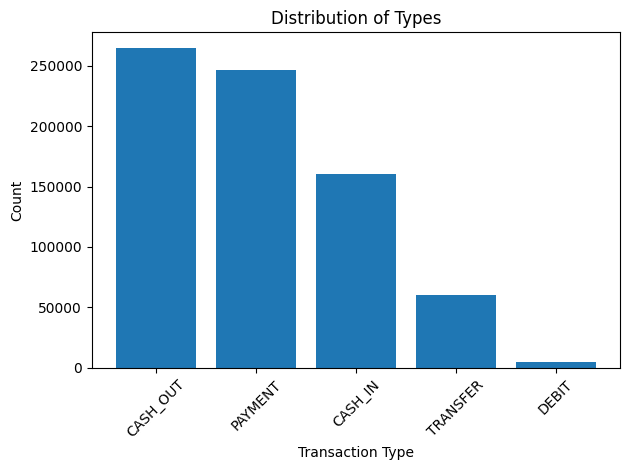

In [8]:
type_counts = df['type'].value_counts()

plt.bar(type_counts.index, type_counts.values)
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


/tmp/ipython-input-10-3510430398.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraudulent_payment_counts.index, y=fraudulent_payment_counts.values, palette='viridis')


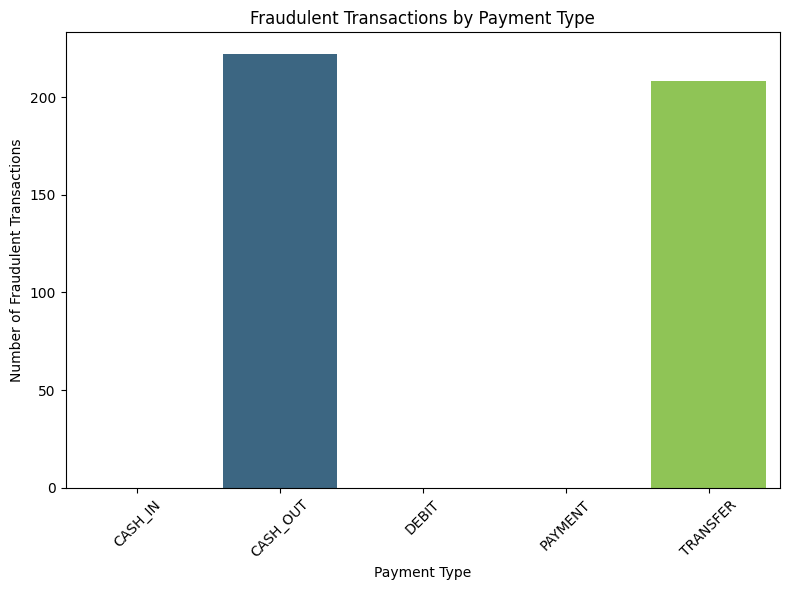

In [10]:


fraudulent_df = df[df['isFraud'] == 1]


all_types = sorted(df['type'].unique())

# Count the occurrences of each payment type in fraudulent transactions
fraudulent_payment_counts = fraudulent_df['type'].value_counts().reindex(all_types, fill_value=0)

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=fraudulent_payment_counts.index, y=fraudulent_payment_counts.values, palette='viridis')
plt.xlabel('Payment Type')
plt.ylabel('Number of Fraudulent Transactions')
plt.title('Fraudulent Transactions by Payment Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [12]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,87962,170136.0,160296.36,194703,0.0,0.0,0.0,0.0
1,1,3,1864.28,253896,21249.0,19384.72,202910,0.0,0.0,0.0,0.0
2,1,4,181.00,116049,181.0,0.00,53589,0.0,0.0,1.0,0.0
3,1,1,181.00,675886,181.0,0.00,47685,21182.0,0.0,1.0,0.0
4,1,3,11668.14,398919,41554.0,29885.86,99163,0.0,0.0,0.0,0.0


In [13]:
correlation = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()
print (correlation)

                  amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
amount          1.000000      -0.005318       -0.007419        0.213876   
oldbalanceOrg  -0.005318       1.000000        0.999196        0.093095   
newbalanceOrig -0.007419       0.999196        1.000000        0.094801   
oldbalanceDest  0.213876       0.093095        0.094801        1.000000   
newbalanceDest  0.315211       0.063459        0.063090        0.973914   
isFraud         0.067306       0.000496       -0.006981       -0.004687   

                newbalanceDest   isFraud  
amount                0.315211  0.067306  
oldbalanceOrg         0.063459  0.000496  
newbalanceOrig        0.063090 -0.006981  
oldbalanceDest        0.973914 -0.004687  
newbalanceDest        1.000000 -0.000750  
isFraud              -0.000750  1.000000  


In [ ]:
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [14]:
fraudtransactions = df.loc[df.isFraud ==1].type.value_counts()
print (fraudtransactions)

type
1    222
4    208
Name: count, dtype: int64


In [15]:
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

In [16]:
df['isOrigZero'] = (df['oldbalanceOrg'] == 0).astype(int)

df['isDestZero'] = (df['oldbalanceDest'] == 0).astype(int)

df['isOrigNeg'] = (df['newbalanceOrig'] < 0).astype(int)

df['isDestNeg'] = (df['newbalanceDest'] < 0).astype(int)


In [17]:
df['amt_perc_orig'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df['amt_perc_dest'] = df['amount'] / (df['oldbalanceDest'] + 1)


In [18]:
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud', 'type_encoded'], axis=1, errors='ignore')


In [19]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,isOrigZero,isDestZero,isOrigNeg,isDestNeg,amt_perc_orig,amt_perc_dest
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0,9839.64,0,1,0,0,0.057834,9839.640000
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0,1864.28,0,1,0,0,0.087731,1864.280000
2,1,4,181.00,181.0,0.00,0.0,0.0,1.0,0.0,181.00,0,1,0,0,0.994505,181.000000
3,1,1,181.00,181.0,0.00,21182.0,0.0,1.0,0.0,21363.00,0,0,0,0,0.994505,0.008545
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0,11668.14,0,1,0,0,0.280788,11668.140000


In [20]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

In [21]:
print (df['isFraud'].isnull().sum())

1


In [22]:
df = df.dropna(subset=['isFraud']).astype(int)
df['isFraud'] = df['isFraud'].astype(int)
df = df.reset_index(drop=True)

In [23]:
X = df.drop('isFraud',axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, stratify=y, random_state=42)

In [24]:
print (X_test.head())

        step  type  amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
728675    37     0  313174         501089          814263          170323   
331903    16     0   83220          22096          105316           10701   
139631    11     1  113729        1600851         1487121         3589692   
93050     10     3    8120          21139           13018               0   
144931    11     0  210094         101118          311212            2878   

        newbalanceDest  errorBalanceOrig  errorBalanceDest  isOrigZero  \
728675               0           -626349            483498           0   
331903               0           -166440             93921           0   
139631         3661889                 0             41532           0   
93050                0                 0              8120           0   
144931               0           -420189            212972           0   

        isDestZero  isOrigNeg  isDestNeg  amt_perc_orig  amt_perc_dest  
728675           0 

In [25]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=100, contamination=0.001, random_state=42)
iso.fit(X_train)
X_train['anomaly_score'] = iso.decision_function(X_train)
X_test['anomaly_score'] = iso.decision_function(X_test)



In [26]:
print (X_train['anomaly_score'])


647943    0.275036
479346    0.339346
321726    0.289122
678842    0.231187
494909    0.327043
            ...   
217511    0.282834
468941    0.282290
666059    0.296673
528816    0.269430
210786    0.297747
Name: anomaly_score, Length: 515792, dtype: float64


In [27]:
print (X_test['anomaly_score'])

728675    0.237335
331903    0.318605
139631    0.260520
93050     0.335027
144931    0.300136
            ...   
658745    0.216077
414818    0.332207
198220    0.323440
112564    0.332712
237959    0.086051
Name: anomaly_score, Length: 221055, dtype: float64


In [28]:
from xgboost import XGBClassifier

# Calculate class weights to handle imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)
model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:28:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [32]:
chosen_threshold = 0.3  # To be optimized
y_probs = model.predict_proba(X_test)[:,1]
y_pred = (y_probs > chosen_threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

[[220887     39]
 [    10    119]]
              precision    recall  f1-score   support

           0     1.0000    0.9998    0.9999    220926
           1     0.7532    0.9225    0.8293       129

    accuracy                         0.9998    221055
   macro avg     0.8766    0.9612    0.9146    221055
weighted avg     0.9998    0.9998    0.9998    221055



In [33]:
#Create a pipeline
pipelines = {
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='auc'))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(random_state=42))
    ])
}




Random Forest Classifier Results:
Accuracy: 0.9999773811947253
Confusion Matrix:
 [[220925      1]
 [     4    125]]
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    220926
           1     0.9921    0.9690    0.9804       129

    accuracy                         1.0000    221055
   macro avg     0.9960    0.9845    0.9902    221055
weighted avg     1.0000    1.0000    1.0000    221055



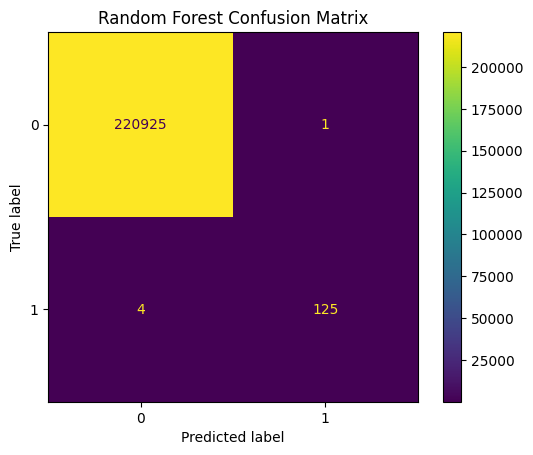

In [34]:
# Instantiate the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf, digits=4))

# Display the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [35]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grids = {
    'XGBoost': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [3, 6, 9],
        'clf__learning_rate': [0.01, 0.1, 0.2],
        'clf__scale_pos_weight': [scale_pos_weight],
      },
    'RandomForest': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_split': [2, 5, 10],
    }
}


Tuning and evaluating: XGBoost
Fitting 2 folds for each of 10 candidates, totalling 20 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:36:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'clf__scale_pos_weight': np.float64(1712.5946843853822), 'clf__n_estimators': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.1}
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    0.9995    0.9997    220926
           1     0.5102    0.9690    0.6684       129

    accuracy                         0.9994    221055
   macro avg     0.7551    0.9842    0.8341    221055
weighted avg     0.9997    0.9994    0.9995    221055

ROC AUC Score: 0.9936


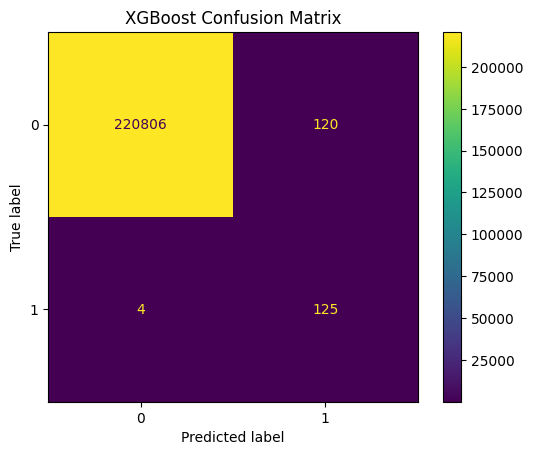


Tuning and evaluating: RandomForest
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best Parameters: {'clf__n_estimators': 200, 'clf__min_samples_split': 10, 'clf__max_depth': 10}
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    220926
           1     0.9921    0.9690    0.9804       129

    accuracy                         1.0000    221055
   macro avg     0.9960    0.9845    0.9902    221055
weighted avg     1.0000    1.0000    1.0000    221055

ROC AUC Score: 0.9891


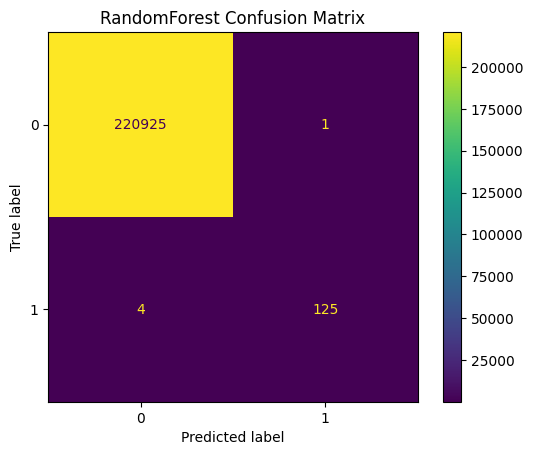

In [36]:


def tune_and_evaluate(name, pipeline, param_grid, X_train, y_train, X_test, y_test):
    print(f"\n{'='*40}\nTuning and evaluating: {name}\n{'='*40}")
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        cv=2,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)

    # Predictions
    y_pred = search.predict(X_test)
    if hasattr(search, "predict_proba"):
        y_proba = search.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc_score = None

    # Print results
    print("Best Parameters:", search.best_params_)
    print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))
    if auc_score is not None:
        print(f"ROC AUC Score: {auc_score:.4f}")

    # Display Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=search.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=search.classes_)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()


    return search.best_estimator_

# Store best models here
best_models = {}

# Loop over all pipelines
for model_name in pipelines.keys():
    best_models[model_name] = tune_and_evaluate(
        model_name,
        pipelines[model_name],
        param_grids[model_name],
        X_train, y_train, X_test, y_test
    )

In [37]:
rf_pipeline = best_models['RandomForest']


In [38]:
rf_model = rf_pipeline.named_steps['clf']
scaler = rf_pipeline.named_steps['scaler']



In [39]:
X_test_scaled = scaler.transform(X_test)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


In [43]:
import shap

In [40]:
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


In [48]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled_df)
print(np.array(shap_values).shape)  # should be (45540, 16)

'''
print(type(shap_values))         # <class 'list'>
print(len(shap_values))          # 2
print(shap_values[0].shape)      # (n_samples, n_features)
print(shap_values[1].shape)
'''

(221055, 16, 2)


"\nprint(type(shap_values))         # <class 'list'>\nprint(len(shap_values))          # 2\nprint(shap_values[0].shape)      # (n_samples, n_features)\nprint(shap_values[1].shape)\n"

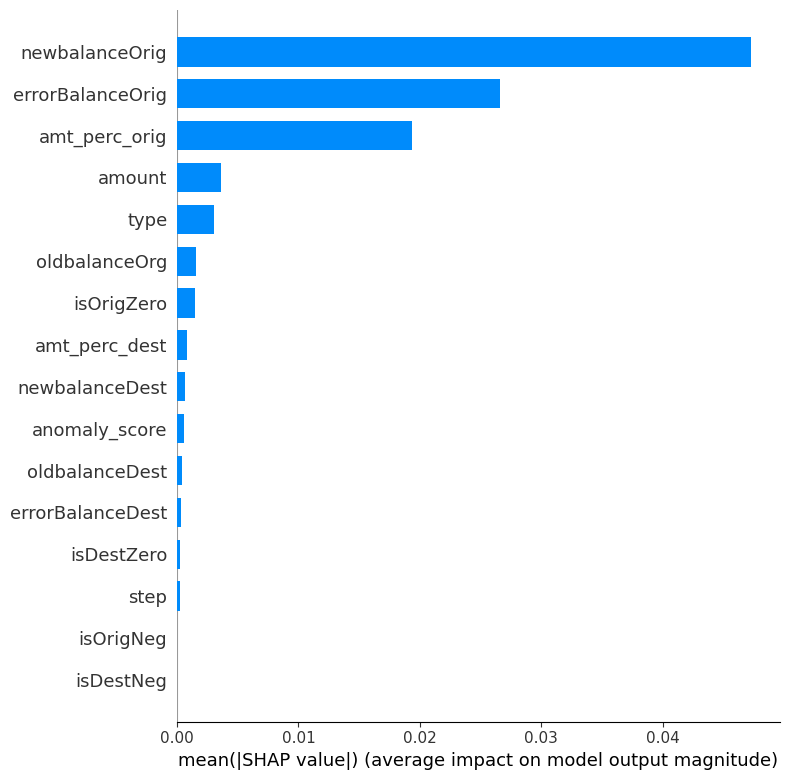

In [49]:
shap.summary_plot(shap_values[:, :, 1], X_test_scaled_df, plot_type='bar')


    step      type      amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
45    26  TRANSFER     3944.81        4634.67          689.86        17708.90   
46     7  TRANSFER     5112.08        9120.37         4008.29         2352.07   
47    25  CASH_OUT    23321.30       27191.48         3870.18         2163.63   
48     4  TRANSFER    11425.67       14421.91         2996.24        13656.10   
49    13   PAYMENT     1389.86        3747.49         2357.63        10905.09   
50     1  TRANSFER        0.00           0.00            0.00            0.00   
51     5  CASH_OUT    10000.00        5000.00        -5000.00        30000.00   
52     3  TRANSFER    20000.00       20000.00            0.00         1000.00   
53     7   PAYMENT  5000000.00       10000.00     -4990000.00            0.00   
54    15  REVERSAL     8000.00        8000.00            0.00        20000.00   

    newbalanceDest  errorBalanceOrig  errorBalanceDest  isOrigZero  \
45        21653.71               0.0  